In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv('data/house_data.csv')

In [4]:
data

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09 00:00:00,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA


In [5]:
data.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

In [6]:
data = data[['price','waterfront','sqft_living','bedrooms','bathrooms','floors','condition']]

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   price        4600 non-null   float64
 1   waterfront   4600 non-null   int64  
 2   sqft_living  4600 non-null   int64  
 3   bedrooms     4600 non-null   float64
 4   bathrooms    4600 non-null   float64
 5   floors       4600 non-null   float64
 6   condition    4600 non-null   int64  
dtypes: float64(4), int64(3)
memory usage: 251.7 KB


In [7]:
data.loc[10:20, 'bedrooms'] = np.nan

In [8]:
data.head(30)

,price,waterfront,sqft_living,bedrooms,bathrooms,floors,condition
0,313000.0,0,1340,3.0,1.50,1.5,3
1,2384000.0,0,3650,5.0,2.50,2.0,5
2,342000.0,0,1930,3.0,2.00,1.0,4
3,420000.0,0,2000,3.0,2.25,1.0,4
4,550000.0,0,1940,4.0,2.50,1.0,4
5,490000.0,0,880,2.0,1.00,1.0,3
6,335000.0,0,1350,2.0,2.00,1.0,3
7,482000.0,0,2710,4.0,2.50,2.0,3
8,452500.0,0,2430,3.0,2.50,1.0,4
9,640000.0,0,1520,4.0,2.00,1.5,3


In [9]:
missing = data.isna().sum()

In [13]:
missing

price           0
waterfront      0
sqft_living     0
bedrooms       11
bathrooms       0
floors          0
condition       0
dtype: int64

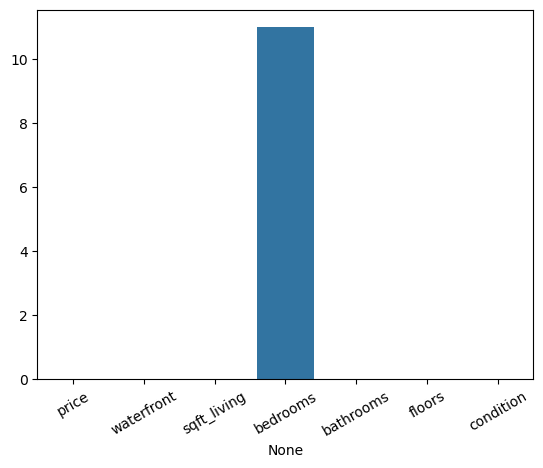

In [10]:
sns.barplot(x=missing.index,y=missing.values)
plt.xticks(rotation=30);

<Axes: xlabel='price', ylabel='Count'>

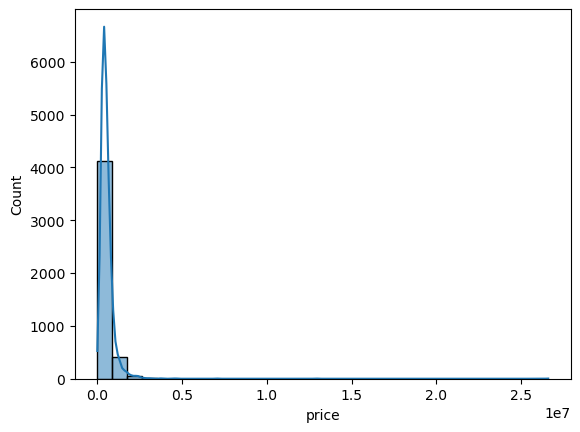

In [11]:
sns.histplot(data['price'],kde=True,bins=30)

<Axes: >

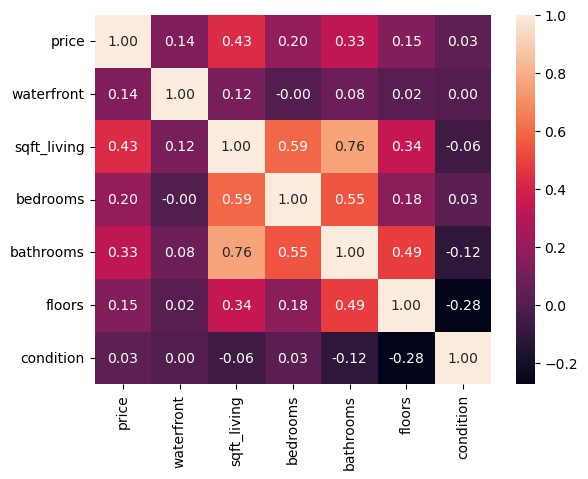

In [18]:
sns.heatmap(data.corr(numeric_only=True),annot=True,fmt='.2f')

In [12]:
from sklearn.impute import SimpleImputer

In [13]:
imp = SimpleImputer(strategy='median')
data['bedrooms'] = imp.fit_transform(data[['bedrooms']])

In [15]:
data.head(30)

,price,waterfront,sqft_living,bedrooms,bathrooms,floors,condition
0,313000.0,0,1340,3.0,1.50,1.5,3
1,2384000.0,0,3650,5.0,2.50,2.0,5
2,342000.0,0,1930,3.0,2.00,1.0,4
3,420000.0,0,2000,3.0,2.25,1.0,4
4,550000.0,0,1940,4.0,2.50,1.0,4
5,490000.0,0,880,2.0,1.00,1.0,3
6,335000.0,0,1350,2.0,2.00,1.0,3
7,482000.0,0,2710,4.0,2.50,2.0,3
8,452500.0,0,2430,3.0,2.50,1.0,4
9,640000.0,0,1520,4.0,2.00,1.5,3


In [16]:
data['waterfront'].dtype

dtype('int64')

In [17]:
data.isna().sum()

price          0
waterfront     0
sqft_living    0
bedrooms       0
bathrooms      0
floors         0
condition      0
dtype: int64

In [18]:
data.loc[50,'price'] = data['price'].mean()*10

<Axes: xlabel='price'>

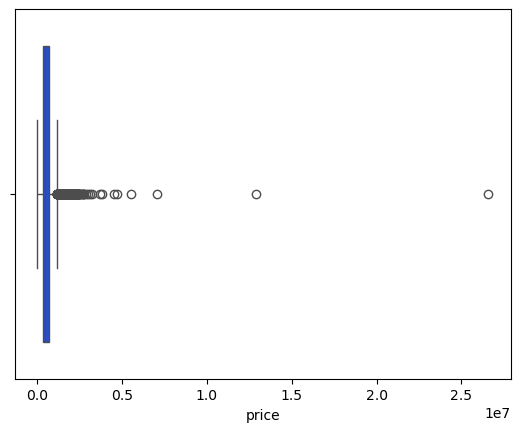

In [19]:
sns.boxplot(x=data['price'],palette='bright')

In [23]:
q1 = data['price'].quantile(0.25)
q3 = data['price'].quantile(0.75)
iqr = q3-q1
lower = q1-1.5*iqr
upper = q3+1.5*iqr

In [26]:
data = data[(data['price']>=lower)&(data['price']<=upper)]

In [28]:
data['price'].max()

1150000.0

<Axes: xlabel='price'>

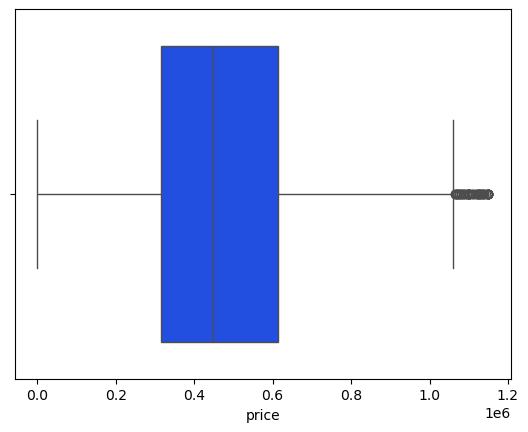

In [29]:
sns.boxplot(x=data['price'],palette='bright')

In [30]:
from sklearn.preprocessing import StandardScaler

In [31]:
SSC = StandardScaler()

In [32]:
data.columns

Index(['price', 'waterfront', 'sqft_living', 'bedrooms', 'bathrooms', 'floors',
       'condition'],
      dtype='object')

In [33]:
data[['sqft_living', 'bedrooms', 'bathrooms', 'floors',
       'condition']] = SSC.fit_transform(data[['sqft_living', 'bedrooms', 'bathrooms', 'floors',
       'condition']])

In [34]:
data


,price,waterfront,sqft_living,bedrooms,bathrooms,floors,condition
0,313000.000000,0,-0.850598,-0.40430,-0.829139,0.009192,-0.664877
2,342000.000000,0,-0.132686,-0.40430,-0.139337,-0.922595,0.824434
3,420000.000000,0,-0.047510,-0.40430,0.205564,-0.922595,0.824434
4,550000.000000,0,-0.120518,0.72396,0.550465,-0.922595,0.824434
5,490000.000000,0,-1.410325,-1.53256,-1.518941,-0.922595,-0.664877
...,...,...,...,...,...,...,...
4595,308166.666667,0,-0.643742,-0.40430,-0.484238,-0.922595,0.824434
4596,534333.333333,0,-0.704582,-0.40430,0.550465,0.940979,-0.664877
4597,416904.166667,0,1.181456,-0.40430,0.550465,0.940979,-0.664877
4598,203400.000000,0,0.062001,0.72396,-0.139337,-0.922595,-0.664877


In [35]:
X = data.drop('waterfront',axis=1)
y = data['waterfront']

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [38]:
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor

In [41]:
knn_cl = KNeighborsClassifier(n_neighbors=5,metric='l2')

In [42]:
knn_cl.fit(X_train,y_train)

KNeighborsClassifier(metric='l2')

In [43]:
y_pred = knn_cl.predict(X_test)

In [44]:
from sklearn.metrics import accuracy_score

In [45]:
accuracy_score(y_test,y_pred)

0.9988532110091743

In [46]:
X = data.drop('price',axis=1)
y = data['price']

In [47]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [48]:
knn_rg = KNeighborsRegressor(n_neighbors=5,metric='l2')

In [49]:
knn_rg.fit(X_train,y_train)

KNeighborsRegressor(metric='l2')

In [50]:
y_pred = knn_rg.predict(X_test)

In [51]:
from sklearn.metrics import r2_score

In [52]:
r2_score(y_test,y_pred)

0.20801737118617059